# ESS — сколько реальных данных заменяет zero-shot LLM

## Цель эксперимента

Мы сравниваем качество zero-shot LLM с качеством обычных ML-моделей,
обученных на разном количестве реальных наблюдений RLMS-HSE.

**ESS** — размер реальной обучающей выборки,
при котором обычная ML-модель достигает качества zero-shot LLM.

### Задачи
- **A1:** прогноз расходов домохозяйства на питание в следующей волне;
- **A2:** прогноз трудового перехода: `same_job`, `different_job`, `no_job`.


## План ноутбука

1. Импорт библиотек.
2. Настройки эксперимента.
3. Поиск и загрузка файлов.
4. Проверка данных.
5. Train / validation / test.
6. Фиксированная evaluation-выборка.
7. Результаты zero-shot LLM.
8. Признаки A1 и A2.
9. Препроцессинг.
10. ML-модели.
11. Метрики.
12. Проверочный запуск.
13. Learning curve A1.
14. Learning curve A2.
15. Расчёт ESS.
16. Графики.
17. Сохранение результатов.


## 1. Импорт библиотек

In [2]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import Ridge, LogisticRegression

from sklearn.ensemble import (
    RandomForestRegressor,
    RandomForestClassifier,
    HistGradientBoostingRegressor,
    HistGradientBoostingClassifier,
)

from sklearn.metrics import (
    mean_absolute_error,
    log_loss,
    f1_score,
)

print("Библиотеки загружены.")

Библиотеки загружены.


## 2. Настройки эксперимента

In [3]:
SEED = 2026

# Размеры реальной обучающей выборки
N_GRID = [
    10, 20, 50, 100, 200,
    500, 1000, 2000, 5000, 10000
]

# Число повторов для каждого N
N_REPEATS = 50

# Для ESS_90:
# минимум 90% повторов должны быть не хуже LLM
ESS_SHARE = 0.90

# Основная zero-shot LLM
PRIMARY_LLM = "Qwen/Qwen2.5-1.5B-Instruct"

print("SEED =", SEED)
print("N_GRID =", N_GRID)
print("N_REPEATS =", N_REPEATS)
print("PRIMARY_LLM =", PRIMARY_LLM)

SEED = 2026
N_GRID = [10, 20, 50, 100, 200, 500, 1000, 2000, 5000, 10000]
N_REPEATS = 50
PRIMARY_LLM = Qwen/Qwen2.5-1.5B-Instruct


## 3. Поиск файлов

In [4]:
def find_file(names):
    roots = [
        Path("."),
        Path("/mnt/data"),
        Path("/kaggle/input"),
    ]

    for root in roots:
        if not root.exists():
            continue

        for name in names:
            direct = root / name
            if direct.exists():
                return direct

            hits = list(root.rglob(name))
            if hits:
                return hits[0]

    return None


a1_path = find_file(["a1_pairs.csv", "a1_pairs.csv.gz"])
a2_path = find_file(["a2_pairs.csv", "a2_pairs.csv.gz"])
llm_path = find_file(["llm_summary.json"])

if a1_path is None:
    raise FileNotFoundError(
        "Не найден a1_pairs.csv или a1_pairs.csv.gz"
    )

if a2_path is None:
    raise FileNotFoundError(
        "Не найден a2_pairs.csv или a2_pairs.csv.gz"
    )

if llm_path is None:
    raise FileNotFoundError(
        "Не найден llm_summary.json"
    )

print("A1:", a1_path)
print("A2:", a2_path)
print("LLM:", llm_path)

A1: a1_pairs.csv.gz
A2: a2_pairs.csv.gz
LLM: llm_summary.json


## 4. Загрузка данных

In [5]:
a1 = pd.read_csv(a1_path)
a2 = pd.read_csv(a2_path)

with open(llm_path, encoding="utf-8") as f:
    llm_summary = json.load(f)

print("A1 shape:", a1.shape)
print("A2 shape:", a2.shape)
print("LLM summary загружен.")

A1 shape: (86267, 17)
A2 shape: (106163, 27)
LLM summary загружен.


## 5. Проверка структуры данных

In [6]:
print("A1 columns:")
print(a1.columns.tolist())

print("\nA2 columns:")
print(a2.columns.tolist())

print("\nA1 target:")
print(a1["target_food"].describe())

print("\nA2 target:")
print(a2["target"].value_counts(dropna=False))

A1 columns:
['row_id', 'panel_id', 'year', 'target_year', 'food', 'income', 'hh_size', 'region', 'settlement', 'employed_count', 'children_count', 'adult_count', 'mean_age', 'prev_food', 'prev_income', 'history_years', 'target_food']

A2 columns:
['row_id', 'panel_id', 'year', 'target_year', 'age', 'sex', 'education', 'region', 'settlement', 'marital', 'occupation', 'wage', 'hours', 'expected_reemployment', 'job_loss_risk', 'tenure', 'history_years', 'wage_change', 'occupation_changed', 'prior_job_change', 'openness', 'conscientiousness', 'extraversion', 'agreeableness', 'neuroticism', 'bf_measure_year', 'target']

A1 target:
count    8.626700e+04
mean     1.505394e+04
std      1.265057e+04
min      1.000000e+02
25%      7.000000e+03
50%      1.200000e+04
75%      2.000000e+04
max      1.700000e+06
Name: target_food, dtype: float64

A2 target:
target
same_job         87648
different_job    10622
no_job            7893
Name: count, dtype: int64


## 6. Train / validation / test

Используем временное разделение:

- train: `target_year <= 2021`;
- validation: `2022–2023`;
- test: `target_year >= 2024`.


In [8]:
def split(df):
    train = df[df.target_year <= 2021].copy()
    val = df[df.target_year.between(2022, 2023)].copy()
    test = df[df.target_year >= 2024].copy()

    return train, val, test


a1_train, a1_val, a1_test = split(a1)
a2_train, a2_val, a2_test = split(a2)

print("A1:")
print("train:", len(a1_train))
print("val:  ", len(a1_val))
print("test: ", len(a1_test))

print("\nA2:")
print("train:", len(a2_train))
print("val:  ", len(a2_val))
print("test: ", len(a2_test))

A1:
train: 63832
val:   11202
test:  11233

A2:
train: 79248
val:   13292
test:  13623


## 7. Фиксированная evaluation-выборка

В исходном LLM benchmark:

- A1 - 150 наблюдений;
- A2 - 400 наблюдений.

Используем тот же `random_state=2026`, чтобы ML и LLM сравнивались на одной и той же тестовой подвыборке.

In [9]:
BIG_FIVE = [
    "openness",
    "conscientiousness",
    "extraversion",
    "agreeableness",
    "neuroticism",
]

a1_eval = (
    a1[a1.target_year >= 2024]
    .sample(150, random_state=2026)
    .reset_index(drop=True)
)

a2_eval = (
    a2[
        (a2.target_year >= 2024)
        & a2[BIG_FIVE].notna().all(axis=1)
    ]
    .sample(400, random_state=2026)
    .reset_index(drop=True)
)

print("A1 evaluation:", len(a1_eval))
print("A2 evaluation:", len(a2_eval))

A1 evaluation: 150
A2 evaluation: 400


## 8. Качество zero-shot LLM
Основная модель:

`Qwen/Qwen2.5-1.5B-Instruct`

Метрики:

- A1 - MAE;
- A2 - Brier;
- A2 - macro-F1.

In [10]:
llm = llm_summary["llm_two_seed_summary"][PRIMARY_LLM]

LLM_A1_MAE = float(
    llm["a1"]["mae"]["mean"]
)

LLM_A2_BRIER = float(
    llm["a2_without_personality"]["brier"]["mean"]
)

LLM_A2_F1 = float(
    llm["a2_without_personality"]["macro_f1"]["mean"]
)

print(f"LLM A1 MAE   = {LLM_A1_MAE:.4f}")
print(f"LLM A2 Brier = {LLM_A2_BRIER:.6f}")
print(f"LLM A2 F1    = {LLM_A2_F1:.6f}")

LLM A1 MAE   = 7430.7834
LLM A2 Brier = 0.344935
LLM A2 F1    = 0.307719


## 9. Признаки A1

In [11]:
A1_FEATURES = [
    "year",
    "food",
    "income",
    "hh_size",
    "employed_count",
    "children_count",
    "adult_count",
    "prev_food",
    "prev_income",
]

A1_TARGET = "target_food"

print("A1 features:")
print(A1_FEATURES)

A1 features:
['year', 'food', 'income', 'hh_size', 'employed_count', 'children_count', 'adult_count', 'prev_food', 'prev_income']


## 10. Признаки A2

In [12]:
A2_FEATURES = [
    "year",
    "age",
    "sex",
    "education",
    "settlement",
    "marital",
    "occupation",
    "wage",
    "hours",
    "tenure",
    "history_years",
    "wage_change",
    "occupation_changed",
    "prior_job_change",
]

A2_CAT = [
    "sex",
    "education",
    "settlement",
    "marital",
    "occupation",
]

A2_NUM = [
    x for x in A2_FEATURES
    if x not in A2_CAT
]

CLASSES = np.array([
    "different_job",
    "no_job",
    "same_job",
])

print("A2 features:")
print(A2_FEATURES)

print("\nCategorical:")
print(A2_CAT)

print("\nNumeric:")
print(A2_NUM)

print("\nClasses:")
print(CLASSES)

A2 features:
['year', 'age', 'sex', 'education', 'settlement', 'marital', 'occupation', 'wage', 'hours', 'tenure', 'history_years', 'wage_change', 'occupation_changed', 'prior_job_change']

Categorical:
['sex', 'education', 'settlement', 'marital', 'occupation']

Numeric:
['year', 'age', 'wage', 'hours', 'tenure', 'history_years', 'wage_change', 'occupation_changed', 'prior_job_change']

Classes:
['different_job' 'no_job' 'same_job']


## 11. Проверка столбцов

In [13]:
checks = [
    (A1_FEATURES, a1, "A1", "target_food"),
    (A2_FEATURES, a2, "A2", "target"),
]

for cols, df, name, target in checks:
    required = set(cols + [target, "target_year"])
    missing = sorted(required - set(df.columns))

    if missing:
        raise KeyError(
            f"{name}: отсутствуют колонки {missing}"
        )

    print(f"{name}: все нужные колонки есть.")

A1: все нужные колонки есть.
A2: все нужные колонки есть.


## 12. Препроцессинг

Для числовых признаков:

- пропуски - медиана;
- стандартизация - `StandardScaler`.

Для категориальных:

- пропуски - наиболее частая категория;
- one-hot encoding;


In [14]:
def prep(num, cat):
    transformers = []

    if num:
        transformers.append(
            (
                "num",
                Pipeline([
                    ("imp", SimpleImputer(strategy="median")),
                    ("sc", StandardScaler()),
                ]),
                num,
            )
        )

    if cat:
        try:
            encoder = OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            )
        except TypeError:
            encoder = OneHotEncoder(
                handle_unknown="ignore",
                sparse=False,
            )

        transformers.append(
            (
                "cat",
                Pipeline([
                    (
                        "imp",
                        SimpleImputer(
                            strategy="most_frequent"
                        ),
                    ),
                    ("oh", encoder),
                ]),
                cat,
            )
        )

    return ColumnTransformer(transformers)


print("Препроцессинг готов.")

Препроцессинг готов.


## 13. ML-модели A1

In [15]:
def a1_models():
    return {
        "Ridge": Pipeline([
            ("prep", prep(A1_FEATURES, [])),
            ("model", Ridge(alpha=1.0)),
        ]),

        "RF": Pipeline([
            ("prep", prep(A1_FEATURES, [])),
            (
                "model",
                RandomForestRegressor(
                    n_estimators=200,
                    min_samples_leaf=2,
                    random_state=SEED,
                    n_jobs=-1,
                ),
            ),
        ]),

        "GB": Pipeline([
            ("prep", prep(A1_FEATURES, [])),
            (
                "model",
                HistGradientBoostingRegressor(
                    max_iter=200,
                    learning_rate=0.05,
                    l2_regularization=1.0,
                    random_state=SEED,
                ),
            ),
        ]),
    }


print("A1 models:", list(a1_models().keys()))

A1 models: ['Ridge', 'RF', 'GB']


## 14. ML-модели A2

In [16]:
def a2_models():
    return {
        "Logit": Pipeline([
            (
                "prep",
                prep(A2_NUM, A2_CAT),
            ),
            (
                "model",
                LogisticRegression(
                    max_iter=1000,
                    C=1.0,
                ),
            ),
        ]),

        "RF": Pipeline([
            (
                "prep",
                prep(A2_NUM, A2_CAT),
            ),
            (
                "model",
                RandomForestClassifier(
                    n_estimators=200,
                    min_samples_leaf=3,
                    random_state=SEED,
                    n_jobs=-1,
                ),
            ),
        ]),

        "GB": Pipeline([
            (
                "prep",
                prep(A2_NUM, A2_CAT),
            ),
            (
                "model",
                HistGradientBoostingClassifier(
                    max_iter=200,
                    learning_rate=0.05,
                    l2_regularization=1.0,
                    random_state=SEED,
                ),
            ),
        ]),
    }


print("A2 models:", list(a2_models().keys()))

A2 models: ['Logit', 'RF', 'GB']


## 15. Метрики

### A1
`MAE` — средняя абсолютная ошибка. Чем меньше, тем лучше.

### A2
`Brier score` — качество вероятностного прогноза. Чем меньше, тем лучше.

Дополнительно:

- `macro-F1` — чем больше, тем лучше;
- `log-loss` — чем меньше, тем лучше.

In [17]:
def brier(y, p):
    y = np.asarray(y)

    one = (
        CLASSES[None, :] == y[:, None]
    ).astype(float)

    return float(
        ((p - one) ** 2)
        .sum(axis=1)
        .mean()
    )


def align(model, p):
    out = np.zeros(
        (len(p), len(CLASSES))
    )

    for j, label in enumerate(model.classes_):
        if label in CLASSES:
            idx = np.where(
                CLASSES == label
            )[0][0]

            out[:, idx] = p[:, j]

    return out


def eval_a1(model, tr, te):
    model.fit(
        tr[A1_FEATURES],
        tr["target_food"],
    )

    pred = model.predict(
        te[A1_FEATURES]
    )

    
    pred = np.maximum(0, pred)

    return float(
        mean_absolute_error(
            te["target_food"],
            pred,
        )
    )


def eval_a2(model, tr, te):
    model.fit(
        tr[A2_FEATURES],
        tr["target"],
    )

    p = model.predict_proba(
        te[A2_FEATURES]
    )

    p = align(model, p)

    yhat = CLASSES[
        p.argmax(axis=1)
    ]

    return {
        "brier": brier(
            te["target"],
            p,
        ),
        "log_loss": log_loss(
            te["target"],
            p,
            labels=CLASSES,
        ),
        "macro_f1": f1_score(
            te["target"],
            yhat,
            labels=CLASSES,
            average="macro",
            zero_division=0,
        ),
    }


print("Метрики готовы.")

Метрики готовы.


## 16. Функции случайного выбора обучающей выборки

In [18]:
def sample_train(df, n, seed):
    if n >= len(df):
        return df.copy()

    return df.sample(
        n=n,
        replace=False,
        random_state=seed,
    )


def sample_cls(df, n, seed):
    for k in range(100):
        sample = sample_train(
            df,
            n,
            seed + k,
        )

        if sample["target"].nunique() == len(CLASSES):
            return sample

    return None


print("Функции выборки готовы.")

Функции выборки готовы.


## 17. Проверочный запуск
Проверяем одну небольшую обучающую выборку `N=200`.

In [19]:
N_TEST = 200

sample_a1 = sample_train(
    a1_train,
    N_TEST,
    SEED,
)

sample_a2 = sample_cls(
    a2_train,
    N_TEST,
    SEED,
)

print("A1:")

for name, model in a1_models().items():
    score = eval_a1(
        model,
        sample_a1,
        a1_eval,
    )

    print(
        f"{name}: MAE = {score:.2f}"
    )


print("\nA2:")

for name, model in a2_models().items():
    result = eval_a2(
        model,
        sample_a2,
        a2_eval,
    )

    print(
        f"{name}: "
        f"Brier = {result['brier']:.4f}, "
        f"F1 = {result['macro_f1']:.4f}, "
        f"LogLoss = {result['log_loss']:.4f}"
    )

A1:
Ridge: MAE = 6361.26
RF: MAE = 6749.82
GB: MAE = 6939.43

A2:
Logit: Brier = 0.2316, F1 = 0.3802, LogLoss = 0.4694
RF: Brier = 0.1992, F1 = 0.3130, LogLoss = 0.4056
GB: Brier = 0.2188, F1 = 0.3693, LogLoss = 0.4702


## 18. Learning curve A1

Для каждого N:

1. случайно выбираем N реальных наблюдений из train;
2. обучаем модель;
3. считаем MAE на фиксированной evaluation-выборке;


Получаем среднюю ошибку и разброс.

In [20]:
def run_a1():
    rows = []

    for model_name in ["Ridge", "RF", "GB"]:
        for n in N_GRID:
            errors = []

            for rep in range(N_REPEATS):
                seed = (
                    SEED
                    + rep * 10000
                    + n
                )

                train_sample = sample_train(
                    a1_train,
                    n,
                    seed,
                )

                model = a1_models()[
                    model_name
                ]

                error = eval_a1(
                    model,
                    train_sample,
                    a1_eval,
                )

                errors.append(error)

            errors = np.asarray(errors)

            rows.append({
                "model": model_name,
                "N": min(
                    n,
                    len(a1_train),
                ),
                "mean_mae": errors.mean(),
                "q025": np.quantile(
                    errors,
                    0.025,
                ),
                "q975": np.quantile(
                    errors,
                    0.975,
                ),
                "share_no_worse": np.mean(
                    errors <= LLM_A1_MAE
                ),
                "llm_mae": LLM_A1_MAE,
            })

            print(
                f"A1 | {model_name} | N={n} готово"
            )

    return pd.DataFrame(rows)

## 19. Learning curve A2

Основная метрика для ESS — Brier score.

In [21]:
def run_a2():
    rows = []

    for model_name in ["Logit", "RF", "GB"]:
        for n in N_GRID:
            briers = []
            log_losses = []
            f1_scores = []

            for rep in range(N_REPEATS):
                seed = (
                    SEED
                    + rep * 10000
                    + n
                )

                train_sample = sample_cls(
                    a2_train,
                    n,
                    seed,
                )

                if train_sample is None:
                    continue

                model = a2_models()[
                    model_name
                ]

                result = eval_a2(
                    model,
                    train_sample,
                    a2_eval,
                )

                briers.append(
                    result["brier"]
                )

                log_losses.append(
                    result["log_loss"]
                )

                f1_scores.append(
                    result["macro_f1"]
                )

            rows.append({
                "model": model_name,
                "N": min(
                    n,
                    len(a2_train),
                ),
                "brier_mean": (
                    np.mean(briers)
                    if briers
                    else np.nan
                ),
                "brier_q025": (
                    np.quantile(
                        briers,
                        0.025,
                    )
                    if briers
                    else np.nan
                ),
                "brier_q975": (
                    np.quantile(
                        briers,
                        0.975,
                    )
                    if briers
                    else np.nan
                ),
                "log_loss_mean": (
                    np.mean(log_losses)
                    if log_losses
                    else np.nan
                ),
                "macro_f1_mean": (
                    np.mean(f1_scores)
                    if f1_scores
                    else np.nan
                ),
                "share_no_worse": (
                    np.mean(
                        np.asarray(briers)
                        <= LLM_A2_BRIER
                    )
                    if briers
                    else np.nan
                ),
                "successful_repeats": len(
                    briers
                ),
                "llm_brier": LLM_A2_BRIER,
                "llm_macro_f1": LLM_A2_F1,
            })

            print(
                f"A2 | {model_name} | N={n} готово"
            )

    return pd.DataFrame(rows)

## 20. Запуск основного эксперимента


In [20]:
a1_curve = run_a1()
a2_curve = run_a2()

print("\nA1 learning curve:")
display(a1_curve)

print("\nA2 learning curve:")
display(a2_curve)

A1 | Ridge | N=10 готово
A1 | Ridge | N=20 готово
A1 | Ridge | N=50 готово
A1 | Ridge | N=100 готово
A1 | Ridge | N=200 готово
A1 | Ridge | N=500 готово
A1 | Ridge | N=1000 готово
A1 | Ridge | N=2000 готово
A1 | Ridge | N=5000 готово
A1 | Ridge | N=10000 готово
A1 | RF | N=10 готово
A1 | RF | N=20 готово
A1 | RF | N=50 готово
A1 | RF | N=100 готово
A1 | RF | N=200 готово
A1 | RF | N=500 готово
A1 | RF | N=1000 готово
A1 | RF | N=2000 готово
A1 | RF | N=5000 готово
A1 | RF | N=10000 готово
A1 | GB | N=10 готово
A1 | GB | N=20 готово
A1 | GB | N=50 готово
A1 | GB | N=100 готово
A1 | GB | N=200 готово
A1 | GB | N=500 готово
A1 | GB | N=1000 готово
A1 | GB | N=2000 готово
A1 | GB | N=5000 готово
A1 | GB | N=10000 готово
A2 | Logit | N=10 готово
A2 | Logit | N=20 готово
A2 | Logit | N=50 готово
A2 | Logit | N=100 готово
A2 | Logit | N=200 готово
A2 | Logit | N=500 готово
A2 | Logit | N=1000 готово
A2 | Logit | N=2000 готово
A2 | Logit | N=5000 готово
A2 | Logit | N=10000 готово
A2 | RF | N=

,model,N,mean_mae,q025,q975,share_no_worse,llm_mae
0,Ridge,10,9748.894607,6749.272651,15471.336664,0.16,7430.783427
1,Ridge,20,8421.711063,6896.053493,11659.361194,0.28,7430.783427
2,Ridge,50,7850.297067,6600.645481,9450.161079,0.34,7430.783427
3,Ridge,100,7308.967936,6489.775371,8286.786255,0.64,7430.783427
4,Ridge,200,6914.966537,6379.670196,7709.862877,0.92,7430.783427
5,Ridge,500,7085.575718,6503.295575,7895.758245,0.92,7430.783427
6,Ridge,1000,6868.972498,6514.376414,7458.538683,0.96,7430.783427
7,Ridge,2000,6901.352545,6660.544442,7156.445106,0.98,7430.783427
8,Ridge,5000,6918.574447,6722.239497,7453.442419,0.96,7430.783427
9,Ridge,10000,7033.304496,6739.272524,7571.657654,0.90,7430.783427



A2 learning curve:


,model,N,brier_mean,brier_q025,brier_q975,log_loss_mean,macro_f1_mean,share_no_worse,successful_repeats,llm_brier,llm_macro_f1
0,Logit,10,0.532321,0.216178,1.420848,1.192923,0.293389,0.44,50,0.344935,0.307719
1,Logit,20,0.342942,0.204303,0.819368,0.761039,0.327123,0.68,50,0.344935,0.307719
2,Logit,50,0.306960,0.209591,0.710677,0.689474,0.347816,0.80,50,0.344935,0.307719
3,Logit,100,0.330348,0.225170,0.611193,0.678260,0.362825,0.70,50,0.344935,0.307719
4,Logit,200,0.259196,0.207503,0.373145,0.529388,0.361607,0.96,50,0.344935,0.307719
5,Logit,500,0.225365,0.194666,0.271838,0.456061,0.358052,1.00,50,0.344935,0.307719
6,Logit,1000,0.206570,0.192145,0.223473,0.414692,0.335171,1.00,50,0.344935,0.307719
7,Logit,2000,0.202032,0.192976,0.217107,0.403003,0.326296,1.00,50,0.344935,0.307719
8,Logit,5000,0.196661,0.191454,0.202555,0.390044,0.321011,1.00,50,0.344935,0.307719
9,Logit,10000,0.194730,0.190968,0.199123,0.386365,0.315173,1.00,50,0.344935,0.307719


In [22]:
# Восстанавливаем результаты learning curve

a1_curve = pd.DataFrame([
    ["Ridge", 10, 9748.894607, 0.16],
    ["Ridge", 20, 8421.711063, 0.28],
    ["Ridge", 50, 7850.297067, 0.34],
    ["Ridge", 100, 7308.967936, 0.64],
    ["Ridge", 200, 6914.966537, 0.92],
    ["Ridge", 500, 7085.575718, 0.92],
    ["Ridge", 1000, 6868.972498, 0.96],
    ["Ridge", 2000, 6901.352545, 0.98],
    ["Ridge", 5000, 6918.574447, 0.96],
    ["Ridge", 10000, 7033.304496, 0.90],

    ["RF", 10, 11029.160582, 0.04],
    ["RF", 20, 9242.254034, 0.16],
    ["RF", 50, 8488.679005, 0.28],
    ["RF", 100, 7976.719299, 0.28],
    ["RF", 200, 7234.407832, 0.64],
    ["RF", 500, 7084.335406, 0.80],
    ["RF", 1000, 6939.032430, 0.88],
    ["RF", 2000, 6868.710304, 0.98],
    ["RF", 5000, 6714.531798, 1.00],
    ["RF", 10000, 6693.823804, 1.00],

    ["GB", 10, 14349.516000, 0.00],
    ["GB", 20, 14112.513467, 0.00],
    ["GB", 50, 10216.084718, 0.00],
    ["GB", 100, 8698.479874, 0.10],
    ["GB", 200, 7492.089192, 0.48],
    ["GB", 500, 7273.619713, 0.64],
    ["GB", 1000, 7076.260790, 0.82],
    ["GB", 2000, 6857.868727, 0.96],
    ["GB", 5000, 6683.698023, 1.00],
    ["GB", 10000, 6541.069188, 1.00],
], columns=["model", "N", "mean_mae", "share_no_worse"])


a2_curve = pd.DataFrame([
    ["Logit", 10, 0.532321, 0.44],
    ["Logit", 20, 0.342942, 0.68],
    ["Logit", 50, 0.306960, 0.80],
    ["Logit", 100, 0.330348, 0.70],
    ["Logit", 200, 0.259196, 0.96],
    ["Logit", 500, 0.225365, 1.00],
    ["Logit", 1000, 0.206570, 1.00],
    ["Logit", 2000, 0.202032, 1.00],
    ["Logit", 5000, 0.196661, 1.00],
    ["Logit", 10000, 0.194730, 1.00],

    ["RF", 10, 0.284027, 0.80],
    ["RF", 20, 0.229274, 1.00],
    ["RF", 50, 0.216447, 1.00],
    ["RF", 100, 0.217717, 1.00],
    ["RF", 200, 0.210581, 1.00],
    ["RF", 500, 0.204167, 1.00],
    ["RF", 1000, 0.201623, 1.00],
    ["RF", 2000, 0.200905, 1.00],
    ["RF", 5000, 0.198496, 1.00],
    ["RF", 10000, 0.197159, 1.00],

    ["GB", 10, 0.278880, 0.82],
    ["GB", 20, 0.233190, 1.00],
    ["GB", 50, 0.249386, 0.96],
    ["GB", 100, 0.260364, 0.98],
    ["GB", 200, 0.243600, 1.00],
    ["GB", 500, 0.230144, 1.00],
    ["GB", 1000, 0.217183, 1.00],
    ["GB", 2000, 0.217017, 1.00],
    ["GB", 5000, 0.207136, 1.00],
    ["GB", 10000, 0.198927, 1.00],
], columns=["model", "N", "brier_mean", "share_no_worse"])


print("Результаты learning curve восстановлены.")
print("A1:", a1_curve.shape)
print("A2:", a2_curve.shape)

Результаты learning curve восстановлены.
A1: (30, 4)
A2: (30, 4)


## 21. Расчёт ESS

### ESS_point

Первый N, где средняя ошибка ML не хуже LLM.

### ESS_90

Первый N, где минимум 90% повторов не хуже LLM.

Для A1 и A2 Brier меньше — лучше.

In [24]:
# Расчёт ESS

def calculate_ess_a1(curve):
    rows = []

    for model in curve["model"].unique():
        x = (
            curve[curve["model"] == model]
            .sort_values("N")
        )

        # ESS_point:
        # первое N, где средний MAE ML <= MAE LLM
        point = x[
            x["mean_mae"] <= LLM_A1_MAE
        ]

        # ESS_90:
        # первое N, где минимум 90% повторов
        robust = x[
            x["share_no_worse"] >= ESS_SHARE
        ]

        rows.append({
            "model": model,
            "LLM_MAE": LLM_A1_MAE,
            "ESS_point": (
                int(point.iloc[0]["N"])
                if len(point) > 0
                else None
            ),
            "ESS_90": (
                int(robust.iloc[0]["N"])
                if len(robust) > 0
                else None
            ),
        })

    return pd.DataFrame(rows)


def calculate_ess_a2(curve):
    rows = []

    for model in curve["model"].unique():
        x = (
            curve[curve["model"] == model]
            .sort_values("N")
        )

        # ESS_point по Brier
        point = x[
            x["brier_mean"] <= LLM_A2_BRIER
        ]

        # ESS_90 по Brier
        robust = x[
            x["share_no_worse"] >= ESS_SHARE
        ]

        rows.append({
            "model": model,
            "LLM_Brier": LLM_A2_BRIER,
            "ESS_point": (
                int(point.iloc[0]["N"])
                if len(point) > 0
                else None
            ),
            "ESS_90": (
                int(robust.iloc[0]["N"])
                if len(robust) > 0
                else None
            ),
        })

    return pd.DataFrame(rows)


ESS_A1 = calculate_ess_a1(a1_curve)
ESS_A2 = calculate_ess_a2(a2_curve)

print("A1 ESS")
display(ESS_A1)

print("A2 ESS")
display(ESS_A2)

A1 ESS


,model,LLM_MAE,ESS_point,ESS_90
0,Ridge,7430.783427,100,200
1,RF,7430.783427,200,2000
2,GB,7430.783427,500,2000


A2 ESS


,model,LLM_Brier,ESS_point,ESS_90
0,Logit,0.344935,20,200
1,RF,0.344935,10,20
2,GB,0.344935,10,20


## 22. График A1

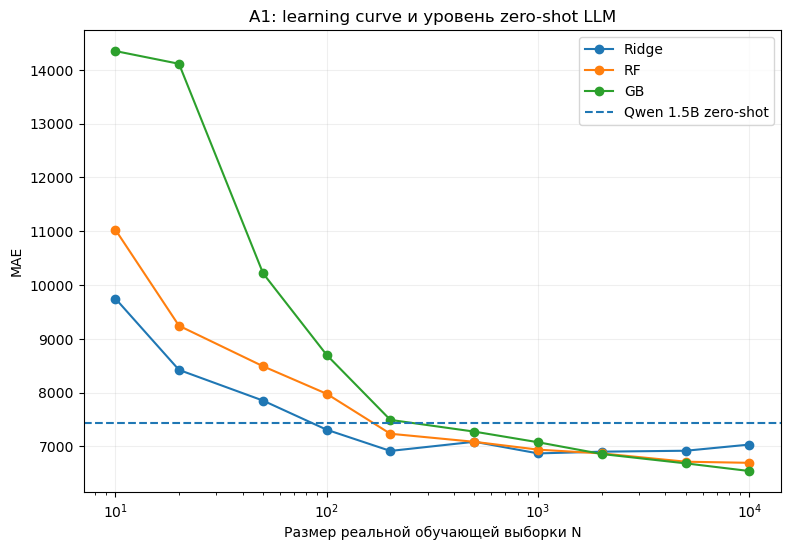

In [25]:
plt.figure(figsize=(9, 6))

for model in a1_curve["model"].unique():
    x = a1_curve[
        a1_curve["model"] == model
    ]

    plt.plot(
        x["N"],
        x["mean_mae"],
        marker="o",
        label=model,
    )

plt.axhline(
    LLM_A1_MAE,
    linestyle="--",
    label="Qwen 1.5B zero-shot",
)

plt.xscale("log")
plt.xlabel(
    "Размер реальной обучающей выборки N"
)
plt.ylabel("MAE")
plt.title(
    "A1: learning curve и уровень zero-shot LLM"
)
plt.grid(alpha=0.2)
plt.legend()
plt.show()

## 23. График A2

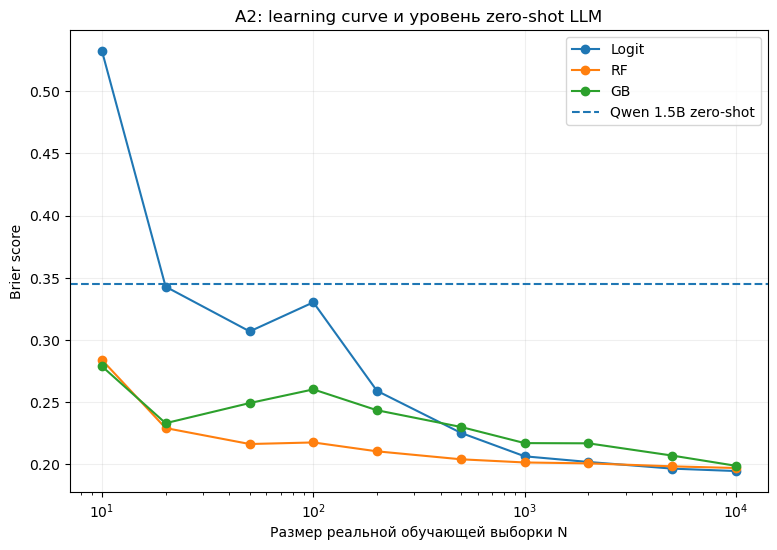

In [23]:
plt.figure(figsize=(9, 6))

for model in a2_curve["model"].unique():
    x = a2_curve[
        a2_curve["model"] == model
    ]

    plt.plot(
        x["N"],
        x["brier_mean"],
        marker="o",
        label=model,
    )

plt.axhline(
    LLM_A2_BRIER,
    linestyle="--",
    label="Qwen 1.5B zero-shot",
)

plt.xscale("log")
plt.xlabel(
    "Размер реальной обучающей выборки N"
)
plt.ylabel("Brier score")
plt.title(
    "A2: learning curve и уровень zero-shot LLM"
)
plt.grid(alpha=0.2)
plt.legend()
plt.show()

## 24. Сохранение результатов

In [24]:
a1_curve.to_csv(
    "ess_a1_learning_curve.csv",
    index=False,
)

a2_curve.to_csv(
    "ess_a2_learning_curve.csv",
    index=False,
)

ESS_A1.to_csv(
    "ess_a1_summary.csv",
    index=False,
)

ESS_A2.to_csv(
    "ess_a2_summary.csv",
    index=False,
)

print("Все результаты сохранены.")

Все результаты сохранены.


**Zero-shot LLM по качеству предсказания эквивалентна примерно 100 реальным наблюдениям для A1 и 10 наблюдениям для A2. При строгом критерии 90% — 200 и 20 наблюдений соответственно**